# Customer Segmentation using Local Models 🚀

โน้ตบุ๊กนี้จะทำการแบ่งกลุ่มลูกค้า (User Segmentation) จากคอมเมนต์ YouTube โดยใช้โมเดล Local ทั้งหมด (ไม่ใช้ API เสียเงิน) 
กระบวนการทำงานมีดังนี้:
1. **Scraping**: ดึงคอมเมนต์จาก YouTube
2. **EDA**: สำรวจข้อมูลเบื้องต้นและสร้าง Word Cloud
3. **Embedding**: แปลงข้อความเป็น Vector ด้วยโมเดล Open Source
4. **Finding Optimal K**: หาจำนวนกลุ่มที่เหมาะสมด้วย Elbow Method
5. **Clustering**: ทดลองใช้ 3 โมเดล (K-Means, Agglomerative, GMM) พร้อม Tuning Hyperparameters
6. **Visualization**: 
    - เปรียบเทียบ 3 โมเดล (3 กราฟ)
    - เปรียบเทียบ PCA vs t-SNE (2 กราฟ)
7. **Keyword Extraction**: ดึงคำสำคัญของแต่ละกลุ่ม
8. **Analysis**: วิเคราะห์และสรุปผลแต่ละกลุ่มด้วย Local LLM

In [16]:
# ติดตั้ง Library ที่จำเป็น (รันครั้งเดียว)
!pip install youtube-comment-downloader pandas scikit-learn seaborn matplotlib sentence-transformers torch transformers accelerate bitsandbytes langchain-huggingface wordcloud

## 1. ดึงข้อมูลคอมเมนต์ (Data Scraping) 📥
ใช้ `youtube_comment_downloader` ในการดึงข้อมูลคอมเมนต์จากวิดีโอที่ต้องการ

In [17]:
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_RECENT
import pandas as pd

def scrape_youtube_comments(video_url, max_comments=300):
    print(f"กำลังดึงคอมเมนต์จาก: {video_url}")
    downloader = YoutubeCommentDownloader()
    generator = downloader.get_comments_from_url(video_url, sort_by=SORT_BY_RECENT)
    
    comments = []
    for count, comment in enumerate(generator):
        if count >= max_comments: break
        comments.append({
            'Author': comment['author'],
            'Comment Text': comment['text']
        })
    
    df = pd.DataFrame(comments)
    df.to_csv('local_youtube_comments.csv', index=False, encoding='utf-8-sig')
    print(f"✅ บันทึก {len(df)} คอมเมนต์เรียบร้อย!")
    return df

# ตัวอย่าง URL (สามารถเปลี่ยนได้)
url = 'https://youtu.be/iogcY_4xGjo?si=yX71k-5LL2baunRC'  # เปลี่ยนเป็น URL ที่ต้องการ
df = scrape_youtube_comments(url, max_comments=300)
df.head()

กำลังดึงคอมเมนต์จาก: https://youtu.be/iogcY_4xGjo?si=yX71k-5LL2baunRC
✅ บันทึก 300 คอมเมนต์เรียบร้อย!


,Author,Comment Text
0,@MrBeast,Stop scrolling and watch the video! You want t...
1,@GlendaGarcia-c2n,😮😮❤❤🎉🎉
2,@loygemaremma,"am watching from uganda, wanna join you some day."
3,@cheatfeatnoproblem,9:03 there painting very similar owi or the so...
4,@woolruuner,Thanks you for iran❤


## 2. สำรวจข้อมูลเบื้องต้น (EDA) 🔍
ดูสถิติพื้นฐานของข้อมูล เช่น ความยาวของคอมเมนต์ และสร้าง Word Cloud เพื่อดูคำที่พบบ่อย

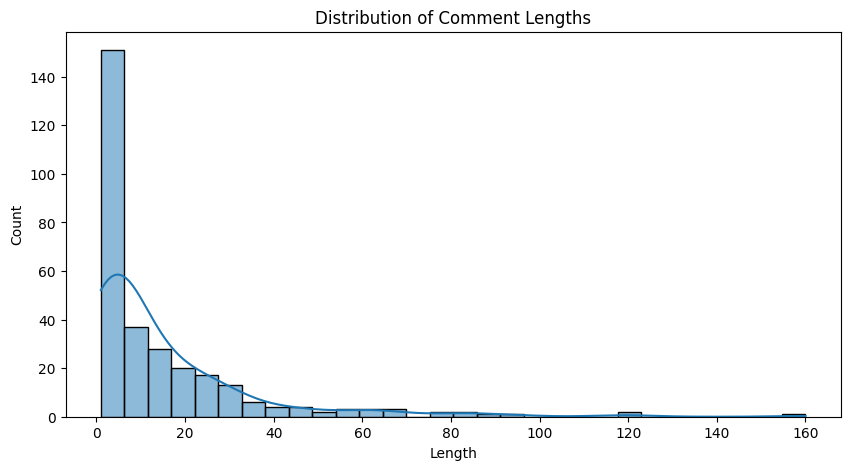

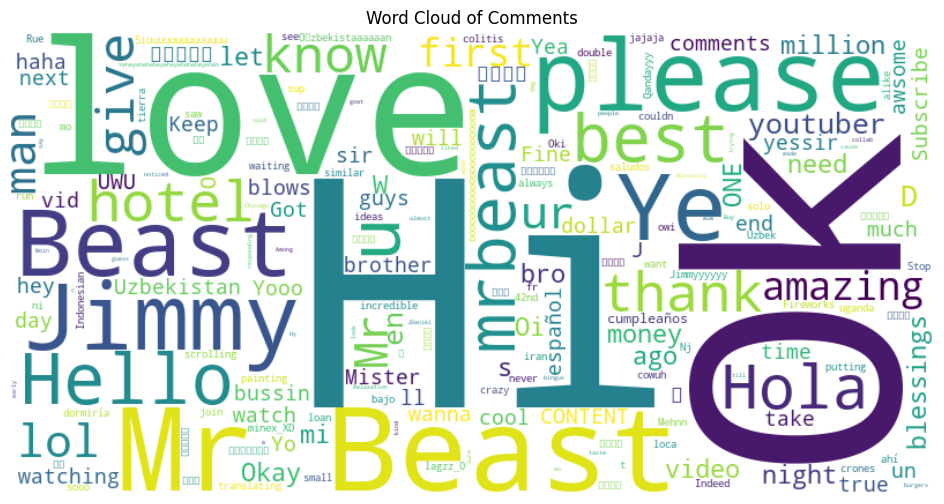

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# เพิ่มคอลัมน์ความยาวตัวอักษร
df['Length'] = df['Comment Text'].apply(len)

# แสดง Histogram ของความยาวคอมเมนต์
plt.figure(figsize=(10, 5))
sns.histplot(df['Length'], bins=30, kde=True)
plt.title('Distribution of Comment Lengths')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

# สร้าง Word Cloud
text_combined = " ".join(comment for comment in df['Comment Text'])

# ใช้ Font ไทยหากมี (หรือใช้ Default ถ้าภาษาอังกฤษเป็นหลัก)
# path_to_font = 'THSarabunNew.ttf' # ถ้ามีไฟล์ฟอนต์ให้ใส่ path ตรงนี้
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Comments')
plt.show()

## 3. สร้าง Embeddings (Text Representation) 🧠
ใช้โมเดล `sentence-transformers/all-MiniLM-L6-v2` หรือโมเดลอื่น ๆ ที่รันบนเครื่อง Local ได้ เพื่อแปลงข้อความเป็น Vector

In [19]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pickle
import os

# ตั้งชื่อไฟล์สำหรับเก็บ Vector Store (Simulation)
VECTOR_STORE_FILE = 'local_vector_store.pkl'

def get_local_embeddings(texts, model_name='all-MiniLM-L6-v2'):
    print(f"🔄 กำลังโหลดโมเดล Embedding: {model_name} ...")
    model = SentenceTransformer(model_name)
    print("🚀 กำลังสร้าง Embeddings...")
    embeddings = model.encode(texts, show_progress_bar=True)
    return embeddings

# ตรวจสอบว่ามีไฟล์ Vector Store อยู่แล้วหรือไม่ เพื่อไม่ต้องคำนวณใหม่
embeddings = None
if os.path.exists(VECTOR_STORE_FILE):
    print(f"✅ พบไฟล์ Vector Store: {VECTOR_STORE_FILE} กำลังโหลด...")
    with open(VECTOR_STORE_FILE, 'rb') as f:
        embeddings = pickle.load(f)
    
    # ตรวจสอบขนาดว่าตรงกับข้อมูลใหม่หรือไม่
    if len(embeddings) != len(df):
        print(f"⚠️ ขนาดไม่ตรงกัน (Embeddings={len(embeddings)}, Data={len(df)}) -> กำลังสร้างใหม่...")
        embeddings = None

if embeddings is None:
    # ถ้ายังไม่มี หรือขนาดไม่ตรง ให้สร้างใหม่
    texts = df['Comment Text'].tolist()
    embeddings = get_local_embeddings(texts)
    
    # บันทึกเก็บไว้ (Vector Store)
    with open(VECTOR_STORE_FILE, 'wb') as f:
        pickle.dump(embeddings, f)
    print(f"💾 บันทึก Vector Store เรียบร้อยที่: {VECTOR_STORE_FILE}")

print(f"ได้ Embeddings ขนาด: {embeddings.shape}")

✅ พบไฟล์ Vector Store: local_vector_store.pkl กำลังโหลด...
ได้ Embeddings ขนาด: (300, 384)


## 4. หาจำนวนกลุ่มที่เหมาะสม (Optimal K) ด้วย Elbow Method 📉
ก่อนจะแบ่งกลุ่ม เราควรหาค่า k (จำนวนกลุ่ม) ที่เหมาะสมที่สุด โดยดูจากจุดที่กราฟเริ่มหักศอก (Elbow)

🔄 กำลังคำนวณ Elbow Method...


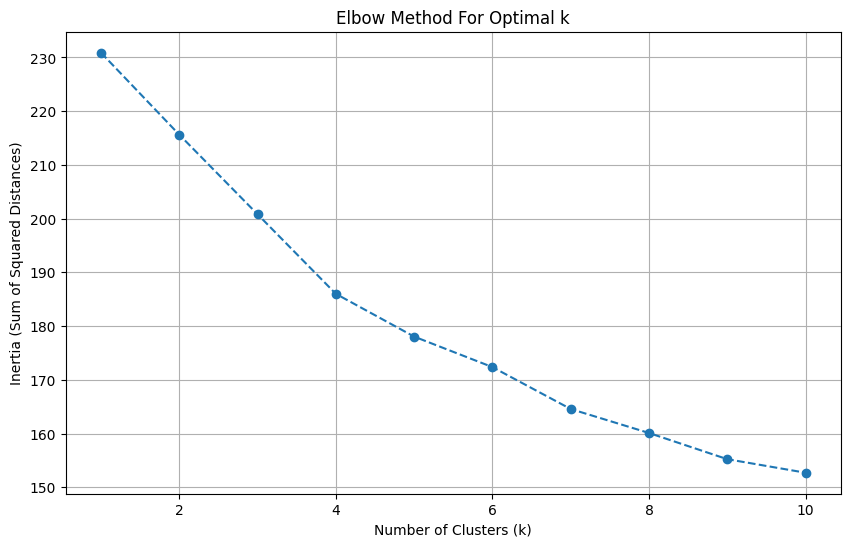

💡 คำแนะนำ: เลือกค่า k ที่กราฟเริ่มมีความชันลดลงอย่างชัดเจน (จุดศอก)


In [20]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

print("🔄 กำลังคำนวณ Elbow Method...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(embeddings)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.show()

print("💡 คำแนะนำ: เลือกค่า k ที่กราฟเริ่มมีความชันลดลงอย่างชัดเจน (จุดศอก)")

## 5. การจัดกลุ่ม (Clustering) ด้วย 3 โมเดล (พร้อม Tuning Parameters) 🔢

ปรับจูนตัวแปร (Hyperparameters) เพื่อให้โมเดลทำงานได้แม่นยำขึ้น:

### 1. K-Means (Standard)
- **`init='k-means++'`**: เลือกจุดเริ่มต้นแบบฉลาด (Smart Seed) แทนการสุ่มมั่วๆ ช่วยให้ลู่เข้าหาคำตอบที่ดีที่สุดได้เร็วขึ้น
- **`n_init=10`**: รันโมเดลซ้ำ 10 รอบด้วยจุดเริ่มต้นที่ต่างกัน แล้วเลือกผลลัพธ์ที่ดีที่สุด (ลดโอกาสที่ผลจะเพี้ยนเพราะดวงซวยสุ่มจุดเริ่มต้นไม่ดี)
- **`max_iter=300`**: จำนวนรอบสูงสุดในการขยับหาจุดศูนย์กลาง (Centroid) ถ้ายังไม่นิ่งก็จะหยุดที่ 300 รอบ

### 2. Agglomerative Clustering (Hierarchical)
- **`linkage='ward'`**: พยายามทำให้ความแปรปรวนภายในกลุ่ม (Variance) น้อยที่สุด ซึ่งมักจะให้กลุ่มที่มีขนาดเท่าๆ กันและกระชับ
- **`metric='euclidean'`** (หรือ `affinity` ในเวอร์ชันเก่า): ใช้ระยะทางแบบยูคลิด ซึ่งเข้ากันได้ดีกับ Ward Linkage

### 3. Gaussian Mixture Models (GMM) (Advanced)
- **`covariance_type='full'`**: อนุญาตให้กลุ่มมีรูปร่างเป็นวงรีที่เอียงไปทิศทางไหนก็ได้ (ยืดหยุ่นที่สุด) ต่างจาก K-Means ที่บังคับเป็นวงกลม
- **`n_init=5`**: เนื่องจาก GMM ใช้วิธี Expectation-Maximization ซึ่งอาจติด Local Optima ได้ง่าย การรันซ้ำ 5 รอบช่วยเพิ่มความเสถียร

In [21]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# กำหนดค่าพารามิเตอร์
num_clusters = 5
seed = 42

print(f"⚙️ เริ่มทำ Clustering ด้วย 3 โมเดล (n_clusters={num_clusters}) พร้อม Hyperparameter Tuning...\n")

# 1. K-Means (Tuned)
# init='k-means++' ช่วยให้เริ่มจุด centroid ได้ดีกว่าสุ่ม
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', max_iter=300, n_init=10, random_state=seed)
df['Cluster_KMeans'] = kmeans.fit_predict(embeddings)
score_kmeans = silhouette_score(embeddings, df['Cluster_KMeans'])
print(f"✅ K-Means Done. (Score: {score_kmeans:.4f})")

# 2. Agglomerative Clustering (Tuned)
# linkage='ward' เหมาะสำหรับข้อมูลที่ต้องการความกระชับ (compact clusters)
# ใช้ metric='euclidean' แทน affinity='euclidean' (เพราะ affinity ถูกถอดออกใน sklearn เวอร์ชันใหม่)
try:
    agg = AgglomerativeClustering(n_clusters=num_clusters, linkage='ward', metric='euclidean')
except TypeError:
    # Fallback สำหรับ sklearn เวอร์ชันเก่าที่ยังใช้ affinity
    agg = AgglomerativeClustering(n_clusters=num_clusters, linkage='ward', affinity='euclidean')

df['Cluster_Agg'] = agg.fit_predict(embeddings)
score_agg = silhouette_score(embeddings, df['Cluster_Agg'])
print(f"✅ Agglomerative Done. (Score: {score_agg:.4f})")

# 3. Gaussian Mixture Models (GMM) (Tuned)
# n_init=5 ช่วยป้องกันการติด Local Optima
# covariance_type='full' ยืดหยุ่นสูงสุด
gmm = GaussianMixture(n_components=num_clusters, covariance_type='full', max_iter=200, n_init=5, random_state=seed)
df['Cluster_GMM'] = gmm.fit_predict(embeddings)
score_gmm = silhouette_score(embeddings, df['Cluster_GMM'])
print(f"✅ GMM Done. (Score: {score_gmm:.4f})")

# สรุปผล
scores = {'Cluster_KMeans': score_kmeans, 'Cluster_Agg': score_agg, 'Cluster_GMM': score_gmm}
best_model_name = max(scores, key=scores.get)
print(f"\n🏆 โมเดลผู้ชนะคือ: {best_model_name} (คะแนน {scores[best_model_name]:.4f})")

# เลือกโมเดลที่ดีที่สุดมาใช้ต่อ
target_column = best_model_name

⚙️ เริ่มทำ Clustering ด้วย 3 โมเดล (n_clusters=5) พร้อม Hyperparameter Tuning...

✅ K-Means Done. (Score: 0.1640)
✅ Agglomerative Done. (Score: 0.1623)
✅ GMM Done. (Score: 0.1239)

🏆 โมเดลผู้ชนะคือ: Cluster_KMeans (คะแนน 0.1640)


## 6. Visualization 🎨 (Model Comparison & t-SNE)
ส่วนนี้เราจะแสดงผล 2 ส่วน:
1. **Model Comparison**: เปรียบเทียบผลลัพธ์ของ 3 โมเดล (ดูว่าแต่ละโมเดลแบ่งกลุ่มต่างกันอย่างไร)
2. **Technique Comparison**: เปรียบเทียบ PCA vs t-SNE (t-SNE มักจะแยกกลุ่มได้สวยกว่า)

🎨 กำลังสร้าง Visualization...


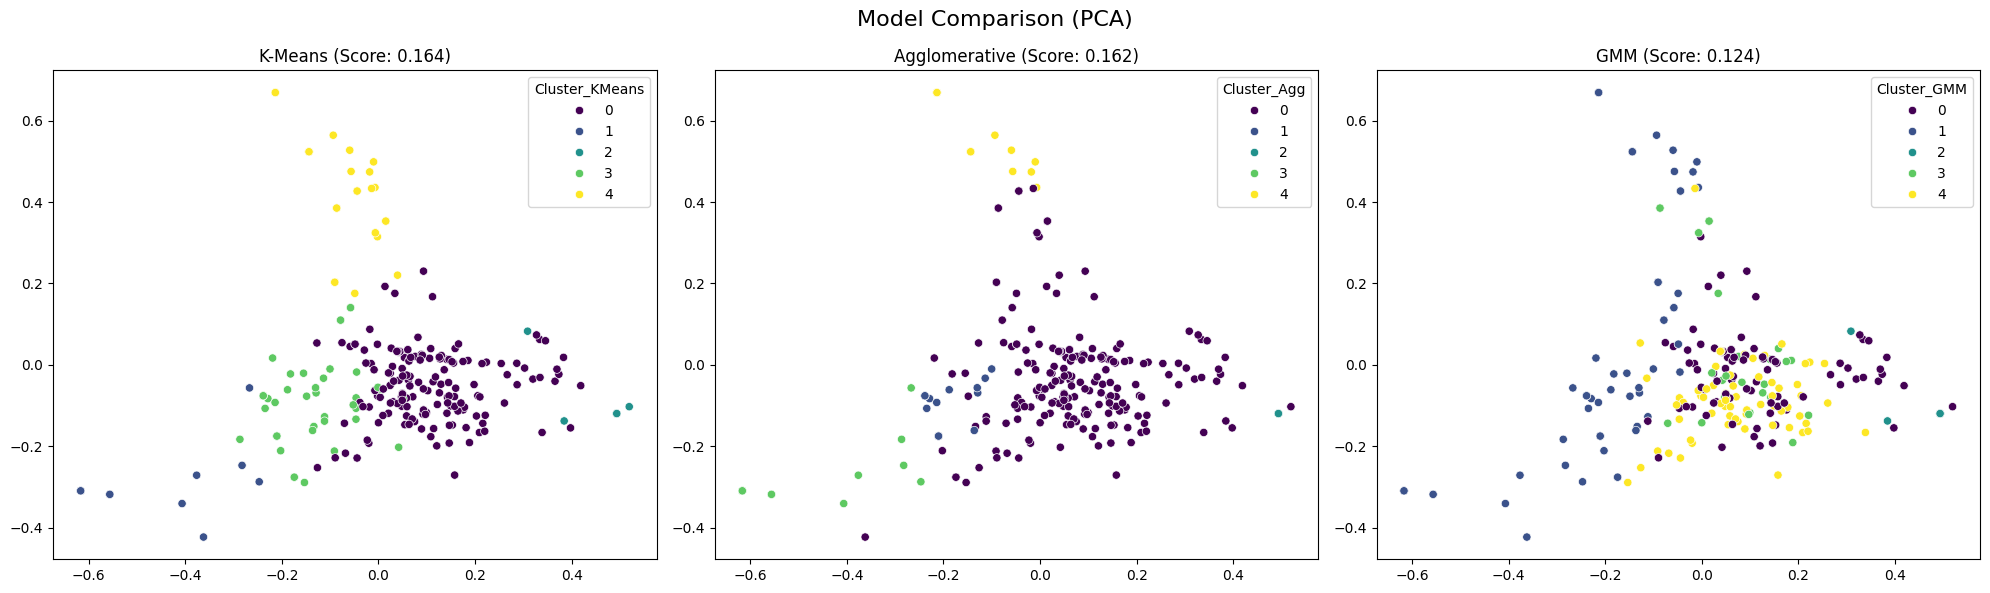


🔥 แสดงผล Visualization แบบละเอียดสำหรับโมเดล: Cluster_KMeans


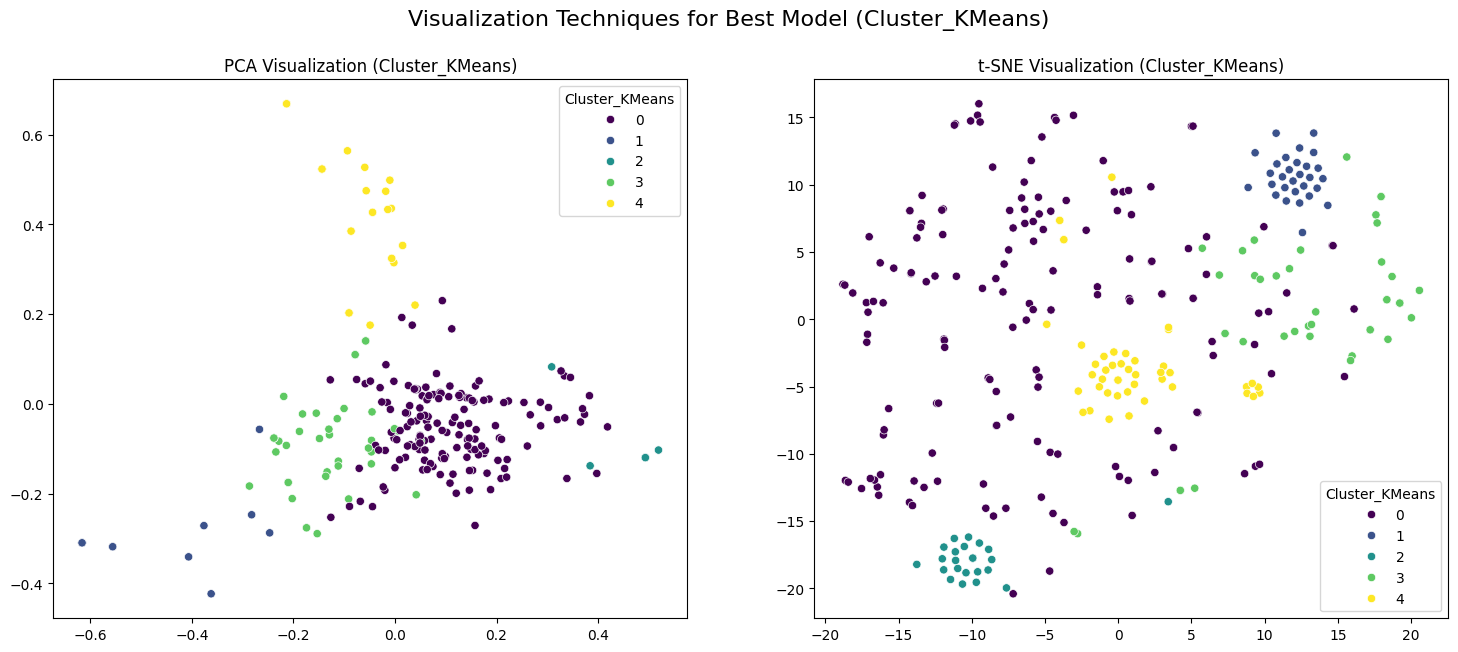

In [22]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("🎨 กำลังสร้าง Visualization...")

# --- 1. เปรียบเทียบโมเดล 3 ตัว (ใช้ PCA เพื่อความรวดเร็วในการพลอต) ---
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(embeddings)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x=reduced_vectors[:,0], y=reduced_vectors[:,1], hue=df['Cluster_KMeans'], palette='viridis', ax=axes[0])
axes[0].set_title(f'K-Means (Score: {score_kmeans:.3f})')

sns.scatterplot(x=reduced_vectors[:,0], y=reduced_vectors[:,1], hue=df['Cluster_Agg'], palette='viridis', ax=axes[1])
axes[1].set_title(f'Agglomerative (Score: {score_agg:.3f})')

sns.scatterplot(x=reduced_vectors[:,0], y=reduced_vectors[:,1], hue=df['Cluster_GMM'], palette='viridis', ax=axes[2])
axes[2].set_title(f'GMM (Score: {score_gmm:.3f})')

plt.suptitle("Model Comparison (PCA)", fontsize=16)
plt.tight_layout()
plt.show()

# --- 2. เปรียบเทียบ Visualization Technique (PCA vs t-SNE) สำหรับโมเดลที่ดีที่สุด (Winner) ---
print(f"\n🔥 แสดงผล Visualization แบบละเอียดสำหรับโมเดล: {target_column}")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA Plot
sns.scatterplot(x=reduced_vectors[:,0], y=reduced_vectors[:,1], hue=df[target_column], palette='viridis', ax=axes[0])
axes[0].set_title(f'PCA Visualization ({target_column})')

# t-SNE Plot
# perplexity ควรปรับตามจำนวนข้อมูล (เช่น 5-50)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_res = tsne.fit_transform(embeddings)
sns.scatterplot(x=tsne_res[:,0], y=tsne_res[:,1], hue=df[target_column], palette='viridis', ax=axes[1])
axes[1].set_title(f't-SNE Visualization ({target_column})')

plt.suptitle(f"Visualization Techniques for Best Model ({target_column})", fontsize=16)
plt.show()

## 7. Keyword Extraction ดึงคำสำคัญประจำกลุ่ม 🔑
หา Top Keywords ของแต่ละกลุ่ม เพื่อเป็นข้อมูลประกอบการวิเคราะห์ให้ LLM

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_keywords(data, n_top=10):
    if len(data) == 0: return []
    vec = CountVectorizer(stop_words='english')
    try:
        bag_of_words = vec.fit_transform(data)
        sum_words = bag_of_words.sum(axis=0) 
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
        return [w[0] for w in words_freq[:n_top]]
    except ValueError:
        return [] # กรณีข้อมูลน้อยเกินไปหรือมีแต่ stop words

print("🔑 Top Keywords per Cluster:")
for i in range(num_clusters):
    cluster_texts = df[df[target_column] == i]['Comment Text'].tolist()
    keywords = get_top_keywords(cluster_texts)
    print(f"Group {i}: {keywords}")

🔑 Top Keywords per Cluster:
Group 0: ['beast', 'mr', 'love', 'best', 'jimmy', 'hotel', '000', 'man', 'ur', 'amazing']
Group 1: ['ok', 'okay', 'lol', 'fine']
Group 2: ['oʻzbekistaaaaaan', 'ooooooooooooooooooooooœ', '今でも見てる人', 'qandayyy', 'minex_xd', 'holanolo', '1dfrhrjtrj', 'ola', 'oi', 'mrbeast']
Group 3: ['yes', 'true', 'yooo', 'yessir', 'ye', 'oi', 'know', 'yea', 'oki', 'obviously']
Group 4: ['hi', 'hola', 'hello', 'beast', 'mr', 'jimmy', 'mrbeast', 'cowuh', 'saw', 'nj']


## 8. วิเคราะห์และสรุปผลด้วย Local LLM 🤖
ใช้ `Qwen/Qwen2.5-1.5B-Instruct` สรุป Persona โดยใช้ทั้งคอมเมนต์ตัวอย่างและ Keywords ที่หามาได้

In [24]:
import sys
import os

# เพิ่ม path ให้ Python มองเห็นไฟล์ local_llm.py ในโฟลเดอร์เดียวกัน
sys.path.append(os.getcwd())

try:
    from local_llm import load_local_chat_model
    chat_model = load_local_chat_model(model_name="Qwen/Qwen2.5-1.5B-Instruct") 
except ImportError:
    print("❌ ไม่พบไฟล์ local_llm.py")

from langchain_core.messages import HumanMessage, SystemMessage

def analyze_cluster_with_keywords(cluster_id, sample_comments, keywords):
    prompt = f"""
    วิเคราะห์กลุ่มลูกค้า (Customer Persona) จากข้อมูลต่อไปนี้:
    
    [Top Keywords]: {keywords}
    
    [Sample Comments]:
    {sample_comments}
    
    ------------------------------------
       
    ให้สรุปเป็นหัวข้อดังนี้:
    1. ชื่อกลุ่ม (ตั้งชื่อเท่ๆ ให้กลุ่มนี้)
    2. นิสัย/ความชอบ
    3. อารมณ์ (Positive/Negative/Neutral)
    """
    
    messages = [
        SystemMessage(content="You are a sophisticated data analyst."),
        HumanMessage(content=prompt)
    ]
    
    response = chat_model.invoke(messages)
    return response.content

# วนลูปวิเคราะห์
for i in range(num_clusters):
    print(f"\n🔹 กำลังวิเคราะห์กลุ่มที่ {i}...")
    
    # Sample Comments
    cluster_data = df[df[target_column] == i]['Comment Text']
    cluster_comments = cluster_data.sample(n=min(10, len(cluster_data))).tolist()
    comments_str = "\n- ".join(cluster_comments)
    
    # Keywords
    keywords = get_top_keywords(cluster_data.tolist())
    
    summary = analyze_cluster_with_keywords(i, comments_str, keywords)
    print(summary)
    print("-"*50)


🔹 กำลังวิเคราะห์กลุ่มที่ 0...
### 1. ชื่อกลุ่ม (ตั้งชื่อเท่ๆ ให้กลุ่มนี้)

**The Beast & Jimmy’s Crew**

---

### 2. นิสัย/ความชอบ

* **Beast**: ผู้ที่มีความรักในเรื่องของดนตรีและเกม，《Beast》เป็นเพลงที่พวกเขาชอบเล่น และ《Jimmy》เป็นคนที่พวกเขาชอบสนทนาอยู่เสมอ

* **Jimmy**: เป็นคนที่ชอบแชร์ประสบการณ์และความบันเทิง，《Beast》เป็นคนที่เขาชอบสนทนาและแบ่งปันประสบการณ์กับ Jimmy 

---

### 3. อารมณ์ (Positive/Negative/Neutral)

**Positive**: 

* **The Beast**: เนื้อหาที่เป็นไปได้ว่าพวกเขามีความรู้สึกสนุกสนานจากการสนทนาและสนับสนุนเพลง《Beast》
  
* **Jimmy**: มีความรู้สึกสนุกสนานจากการแบ่งปันประสบการณ์และความบันเทิงที่ทำให้พวกเขาสนับสนุน《Beast》 

**Negative**:

* **None in the list**

**Neutral**:

* **None in the list**
--------------------------------------------------

🔹 กำลังวิเคราะห์กลุ่มที่ 1...
### 1. ชื่อกลุ่ม (ตั้งชื่อเท่ๆ ให้กลุ่มนี้)

**Okies, Lovers!**

### 2. นิสัย/ความชอบ

- **Likes**: เป็นคนที่ชอบการตอบสนองอย่างตรงจุดและรับฟังทุกคำสัญญาณของผู้อื่น  
- **Tend**: มักจะเลือกใช้ภาษาที่简明扼要